In [1]:
# from data import CARLA_Data
from data_improved import CARLA_Data

# from data_old import CARLA_Data as CARLA_Data_orig
import matplotlib.pyplot as plt
import numpy as np
import cv2
import transfuser_utils as t_u

from config import GlobalConfig
import torch
import numpy as np

config = GlobalConfig()
config.augment = False
config.use_color_aug = False
config.augment_percentage = 1
config.color_aug_prob = 1
config.seq_len = 1
config.seq_step = 1
config.img_seq_len = 1
config.img_step_size = 1
config.lidar_seq_len = 1
config.trajectory_step_size = 1
config.trajectory_pred_len = 5
config.use_trajectory_prediction = True
config.setting = "13_withheld"

In [2]:
from diskcache import Cache

tmp_folder = "/tmp" + "/" + "dataset_cache"
shared_dict = Cache(directory=tmp_folder, size_limit=int(10 * 1024**3))

In [3]:
config.initialize(
    root_dir=[
        "/cluster/work/andrebw/repos/temporal_garage/results/data/garage_v2_2025_03_15/data"
        # "/cluster/work/andrebw/repos/temporal_garage/results/data/garage_v2/data"
    ]
)

dataset = CARLA_Data(
    root=config.data_roots,
    config=config,
    shared_dict=shared_dict,
    estimate_class_distributions=config.estimate_class_distributions,
    estimate_sem_distribution=config.estimate_semantic_distribution,
)

# dataset_old = CARLA_Data_orig(
#     root=config.data_roots,
#     config=config,
#     estimate_class_distributions=config.estimate_class_distributions,
#     estimate_sem_distribution=config.estimate_semantic_distribution,
# )
# Total: 8752
# Standard pruned: 1577
# Only speed pruning: 4413
# Only angle pruning: 1636

# Tot: 335803
# Standard pruning: 155755
# Only speed pruning: 211503
# Only angle pruning: 172423

# seq_len = 2
# Total: 339347 (100%)
# Standard pruning: 199204 (58.7%)
# Speed pruning: 128208 (37.8%)
# Angle pruning: 85534  (25.2%)

# seq_len = 4
# Total: 332259 (100%)
# Standard pruning:

# seq_len = 5
# Total: 328715 (100%)
# Standard pruning: 223967 (68.1%)

Setting:  all
  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 11.26it/s]
Loading 8452 lidars from 3 folders
Total amount of routes: 77
Skipped routes: 2
Trainable routes: 75


In [136]:
device = "cuda"
last_feature = None
BZ = 2
loader = iter(torch.utils.data.DataLoader(dataset, batch_size=BZ))
torch.manual_seed(0)
# loader_old = iter(torch.utils.data.DataLoader(dataset_old, batch_size=BZ))


def extract_data(batch):
    return {
        "rgb": batch.get("temporal_rgb", batch["rgb"]).float().to(device),
        # "rgb": batch["rgb"].float().to(device),
        # "lidar_bev": batch.get("temporal_lidar", batch["lidar"]).float().to(device),
        "lidar_bev": batch["lidar"].float().to(device),
        "target_point": batch["target_point"].float().to(device),
        "ego_vel": batch["speed"].float().unsqueeze(1).to(device),
        "command": batch["command"].float().to(device),
    }


def extract_targets(batch):
    return {
        "trajectories": batch["trajectories"].float().to(device),
        "trajectories_mask": batch["trajectories_mask"].float().to(device),
        "target_speed_label": batch["target_speed_twohot"].float().to(device),
        "checkpoint_label": batch["route"][:, : config.predict_checkpoint_len]
        .float()
        .to(device),
        "semantic_label": batch["semantic"].long().to(device),
        "bev_semantic_label": batch["bev_semantic"].long().to(device),
        "depth_label": batch["depth"].float().to(device),
        "center_heatmap_label": batch["center_heatmap"].float().to(device),
        "wh_label": batch["wh"].float().to(device),
        "yaw_class_label": batch["yaw_class"].long().to(device),
        "yaw_res_label": batch["yaw_res"].float().to(device),
        "offset_label": batch["offset"].float().to(device),
        "velocity_label": batch["velocity"].float().to(device),
        "brake_target_label": batch["brake_target"].long().to(device),
        "pixel_weight_label": batch["pixel_weight"].float().to(device),
        "avg_factor_label": batch["avg_factor"].float().to(device),
    }


def unfold_temporaly(data):
    return {k: v.view(4, v.shape[0] // 4, *v.shape[1:]) for k, v in data.items()}


def select(data, i):
    return {k: v[:, i] for k, v in data.items()}


index = 610
# data_point = next(loader)
data_point = {k: torch.tensor(v).unsqueeze(0)  for k,v in dataset[index].items()}

In [36]:
for i in range(100):
    next(loader)

In [116]:
data_point = next(loader)

bev = np.array(config.bev_classes_list)[data_point["bev_semantic"][0].numpy()]
lidar = data_point["lidar"].numpy()[0,:,0]
traj = data_point["trajectories"][0, ].numpy()
mask = data_point["trajectories_mask"][0,].numpy()
traj = traj[np.where(traj.sum(axis=(1,2)) != 0)]
ch = data_point["center_heatmap"][0,:,0].numpy()
bb = data_point['bounding_boxes'][0,:,:].numpy()
rgb = data_point["rgb"][0, :].numpy().transpose(1, 2, 0)


# traj.shape, mask.shape, ch.shape, bb.shape, bev.shape, lidar.shape, rgb.shape

/tmp/ipykernel_730134/736504366.py:21: UserWarning: Attempting to set identical left == right == -0.5 results in singular transformations; automatically expanding.
  plt.imshow(np.rot90(lidar[t], k=1), alpha=0.5)


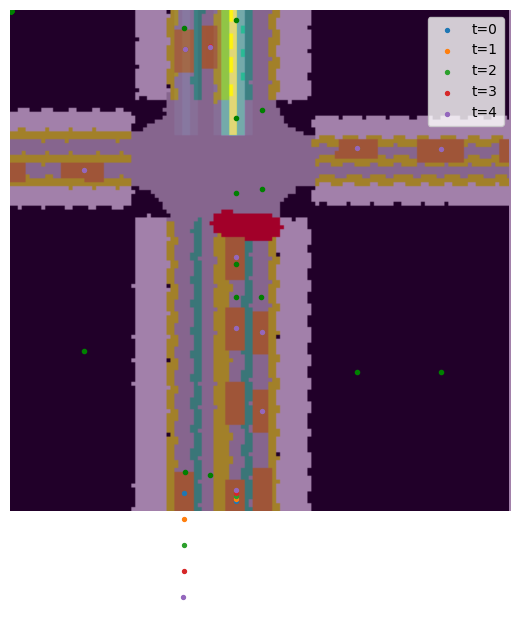

In [180]:
data_point = {k: torch.tensor(v).unsqueeze(0)  for k,v in dataset[index].items()}
# index += 1

bev = np.array(config.bev_classes_list)[data_point["bev_semantic"][0].numpy()]
lidar = data_point["lidar"].numpy()[0,:,0]
traj = data_point["trajectories"][0, ].numpy()
mask = data_point["trajectories_mask"][0,].numpy()
traj = traj[np.where(traj.sum(axis=(1,2)) != 0)]
ch = data_point["center_heatmap"][0,:,0].numpy()
bb = data_point['bounding_boxes'][0,:,:].numpy()
rgb = data_point["rgb"][0, :].numpy().transpose(1, 2, 0)

traj[:,:,1] = 255 - traj[:,:,1]

t = slice(0, -1)
plt.figure(figsize=(8, 8))
# plt.imshow(np.flip(np.rot90(bev[t], k=1), axis=0))
plt.imshow(np.rot90(bev[t], k=1))
plt.imshow(cv2.resize(ch[t], dsize=(256, 256), interpolation=cv2.INTER_NEAREST), alpha=0.5)
# plt.imshow(np.flip(np.rot90(lidar[t], k=1), axis=0), alpha=0.5)
plt.imshow(np.rot90(lidar[t], k=1), alpha=0.5)
# plt.imshow(np.flip(np.rot90(lidar[t+1], k=1), axis=0), alpha=0.5)
for box in bb[t]:
    plt.plot(box[0], box[1], '.', c="green")

# for 
# data_point['route'].numpy()

car = slice(0, -1)
first = True
for i, (car, mask_i) in enumerate(zip(traj[car], mask[car])):
    x = car[np.where(mask_i != -1)][:,0] # * loc_pixels_per_meter + origin[0]
    y = car[np.where(mask_i != -1)][:,1] # * loc_pixels_per_meter + origin[1]
    plt.gca().set_prop_cycle(None)
    for j, (xi, yi) in enumerate(zip(x, y)):
        # print(xi, yi)
        if first: plt.scatter(xi, yi, s=8, label=f"t={j}")
        else: plt.scatter(xi, yi, s=8)
    first = False
    # plt.scatter(x, y, s=8)

# for car in traj[1:2]:
#     for f in car:
#         plt.scatter(f[0], f[1], c="red", s=8)
plt.legend()
plt.axis('off')
plt.show();
# print(mask)
# Do we want to ignore stationary objects?

In [174]:
(loc_pixels_per_meter) + origin[1]

528.0

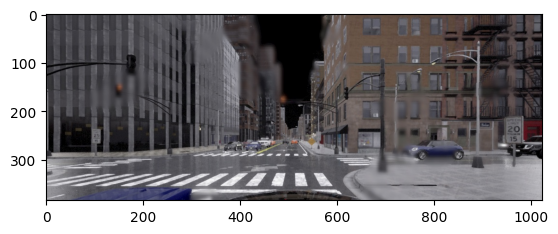

In [168]:
plt.imshow(rgb)

array([250.47122586, 249.62757805, 248.21021979, 246.27078677,
       244.9843943 ])

In [9]:
t = 0
traj = data_point["trajectories"][0, ].numpy()
len([t for t in traj if t.sum() != 0]), len([b for b in bb[t] if b.sum() != 0])

(7, 6)

In [96]:
scale_factor = 4
size_width = int(
    (config.max_y - config.min_y) * config.pixels_per_meter
)
size_height = int(
    (config.max_x - config.min_x) * config.pixels_per_meter
)
origin_x_ratio = (
            config.max_x / (config.max_x - config.min_x)
            if config.crop_bev and config.crop_bev_height_only_from_behind
            else 1
        )
loc_pixels_per_meter = config.pixels_per_meter * scale_factor
origin = (
    (size_width * scale_factor) // 2,
    (origin_x_ratio * size_height * scale_factor) // 2,
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


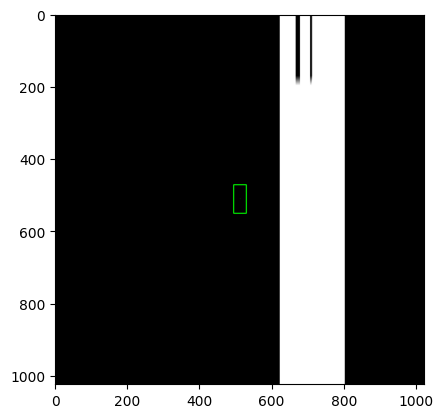

In [101]:
t = -1
w = h = 256 * scale_factor
image = np.zeros((w, h, 3))
bev_i = np.expand_dims(cv2.resize(bev[t].astype(float), dsize=(w,h)), -1)
sample_box = np.array([
        int(w / 2),
        int(origin_x_ratio * h / 2),
        config.ego_extent_x * loc_pixels_per_meter,
        config.ego_extent_y * loc_pixels_per_meter,
        np.deg2rad(90.0),
        0.0,
])
image = bev_i * 0.5 + image * 0.5

image = t_u.draw_box(
    image, sample_box, color=(0, 200, 0), pixel_per_meter=16, thickness=4
)
image = np.rot90(image, k=1)

ch_i = cv2.resize(ch[t], dsize=(w, h), interpolation=cv2.INTER_NEAREST)
image = np.expand_dims(ch_i, -1) * 0.9 + image * 0.1


plt.imshow(image)

In [157]:
for car in traj:
    print()
    for point in car:
        print(point[0], point[1])


145.36944671597865 0.9886511075033582
143.7538588836444 8.269216069675451
142.23280272985102 15.260729075979668
141.24957098764048 19.96708294356631
141.12241757786387 20.589387140259248
0.0 0.0
140.67557862330813 22.902035405626748
140.2820944991616 24.94889561359838
140.21751081050581 25.281156070781606
140.05353636495028 26.147512053739376

143.14778514467264 182.92686539291407
143.6720336534174 191.041469992511
144.24995253725274 198.43973785017624
144.51354172555114 201.5744070642475
144.79130214734522 204.35593377034962
145.12820801437894 207.65766349028092
145.58038679775592 211.83472658687884
146.18545799314757 216.7972534656119
146.84986458739257 222.075709305796
147.71420729905742 228.7502680526075

143.41970329435011 108.74875525107666
142.9196421865504 117.14264288923187
142.6029040012162 124.90213234616004
142.3841220837059 131.59388002876972
142.30725009779025 134.7925712422762
142.28299371200762 137.49265992583588
142.25896860796354 141.416196909049
142.23817694634135 1

(256, 256, 3)


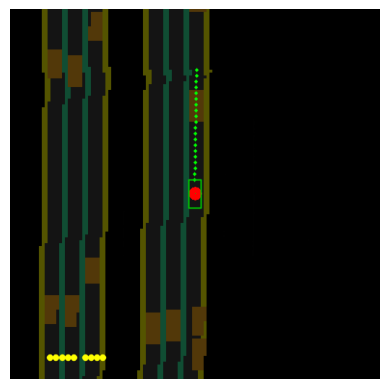

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
lidar = data_point["lidar"][0][0][0].unsqueeze(2).numpy()

# image = np.zeros((256, 256, 3), dtype=np.uint8)
image = lidar


classes_list = np.array(config.bev_classes_list)

bev_indices = data_point["bev_semantic"][0][0]
bev = classes_list[bev_indices]
alpha = np.ones_like(bev) * 0.33
alpha[bev_indices == 0] = 0.0
alpha[bev_indices == 1] = 0.1

image = image * (1 - alpha) + bev * alpha



print(image.shape)

# Plot overlaying lidar and bev_semantic
# plt.imshow(lidar, cmap='gray', alpha=0.5)
# plt.imshow(bev, alpha=0.9)
# plt.imshow(bb, alpha=0.4)

image = cv2.resize(
    image,
    dsize=(
        image.shape[1] * scale_factor,
        image.shape[0] * scale_factor,
    ),
    interpolation=cv2.INTER_NEAREST,
)


image = np.ascontiguousarray(image, dtype=np.uint8)
# Draw a line on the image
for i, car in enumerate(traj):
    for point in car:
        x = point[0].item() * loc_pixels_per_meter + origin[0]
        y = point[1].item() * loc_pixels_per_meter + origin[1]
        # print(x,y)
        if x > 0 and y > 0:
            cv2.circle(
                image,
                (int(x), int(y)),
                radius=8,
                lineType=cv2.LINE_AA,
                color=(255, 0, 0),
                thickness=-1,
            )

gt_checkpoints = data_point["route"][0][0]
for wp in gt_checkpoints.detach().cpu().numpy():
    wp_x = (
        wp[0] * loc_pixels_per_meter + origin[0]
    )  # this is where the minus comes from ^
    wp_y = wp[1] * loc_pixels_per_meter + origin[1]
    # print(wp_x, wp_y)
    cv2.circle(
        image,
        (int(wp_x), int(wp_y)),
        radius=2,
        lineType=cv2.LINE_AA,
        color=(0, 255, 0),
        thickness=-1,
    )

car_i = 4
trajs_i = data_point["trajectories"][0][car_i]
mask_i = data_point["trajectories_mask"][0][car_i]
for wp, m in zip(trajs_i.numpy(), mask_i.numpy()):
    if m == 0:
        continue
    wp_x = (
        wp[0]# * loc_pixels_per_meter + origin[0]
    )  # this is where the minus comes from ^
    wp_y = wp[1]# * loc_pixels_per_meter + origin[1]
    # print(wp_x, wp_y)
    cv2.circle(
        image,
        (int(wp_x), int(wp_y)),
        radius=4,
        lineType=cv2.LINE_AA,
        color=(255, 255, 0),
        thickness=-1,
    )


sample_box = np.array([
        int(w / 2),
        int(origin_x_ratio * h / 2),
        config.ego_extent_x * loc_pixels_per_meter,
        config.ego_extent_y * loc_pixels_per_meter,
        np.deg2rad(90.0),
        0.0,
])
image = t_u.draw_box(
    image, sample_box, color=(0, 200, 0), pixel_per_meter=16, thickness=2
)


image = np.rot90(image, k=1)

# for car, mask_i in zip(traj, mask):
#     x = car[np.where(mask_i == 1), 0].squeeze()
#     y = car[np.where(mask_i == 1), 1].squeeze()
#     plt.plot(x, y, linewidth=2)
plt.axis("off")
plt.imshow(image)


In [ ]:
trajs

tensor([[ 29.6525, 128.4828],
        [ 29.6373, 120.3896],
        [ 29.6250, 112.0843],
        [ 29.6165, 104.1893],
        [  0.0000,   0.0000],
        [ 29.6058,  88.0601],
        [ 29.6017,  80.0476],
        [ 29.5974,  72.0010],
        [ 29.5951,  63.9533],
        [ 29.5938,  55.9173]], dtype=torch.float64)

In [ ]:
data_point["trajectories"][0][car_i]

tensor([[  0.0000,   0.0000],
        [  0.0000,   0.0000],
        [  0.0000,   0.0000],
        [  0.0000,   0.0000],
        [  0.0000,   0.0000],
        [  0.0000,   0.0000],
        [  0.0000,   0.0000],
        [  0.0000,   0.0000],
        [ 30.0052, 227.2848],
        [  0.0000,   0.0000]], dtype=torch.float64)

In [ ]:
trajs = data_point["trajectories"][0][0]
trajs.shape


torch.Size([10, 2])

In [ ]:
traj.shape

torch.Size([6, 6, 2])

In [ ]:
import cv2
import transfuser_utils as t_u
scale_factor = 4
size_width = int(
    (config.max_y - config.min_y) * config.pixels_per_meter
)
size_height = int(
    (config.max_x - config.min_x) * config.pixels_per_meter
)
origin_x_ratio = (
            config.max_x / (config.max_x - config.min_x)
            if config.crop_bev and config.crop_bev_height_only_from_behind
            else 1
        )
loc_pixels_per_meter = config.pixels_per_meter * scale_factor
origin = (
    (size_width * scale_factor) // 2,
    (origin_x_ratio * size_height * scale_factor) // 2,
)

lidar_bev = data_point["lidar"][0]
images_lidar = np.concatenate(
    list(lidar_bev.detach().cpu().numpy()[0][:1]), axis=1
)
images_lidar = 255 - (images_lidar * 255).astype(np.uint8)
images_lidar = np.stack([images_lidar, images_lidar, images_lidar], axis=-1)

images_lidar = cv2.resize(
    images_lidar,
    dsize=(
        images_lidar.shape[1] * scale_factor,
        images_lidar.shape[0] * scale_factor,
    ),
    interpolation=cv2.INTER_NEAREST,
)
images_lidar.shape


(1024, 1024, 3)

In [ ]:
pred_bev_semantic = data_point["bev_semantic"][0][0]

converter = np.array(config.bev_classes_list)
converter[1][0:3] = 40
bev_semantic_image = converter[pred_bev_semantic].astype("uint8")
alpha = np.ones_like(pred_bev_semantic) * 0.33
alpha = alpha.astype(np.float32)
alpha[pred_bev_semantic == 0] = 0.0
alpha[pred_bev_semantic == 1] = 1.0

alpha = cv2.resize(
    alpha,
    dsize=(alpha.shape[1] * scale_factor, alpha.shape[0] * scale_factor),
    interpolation=cv2.INTER_NEAREST,
)
alpha = np.expand_dims(alpha, 2)
bev_semantic_image = cv2.resize(
    bev_semantic_image,
    dsize=(
        bev_semantic_image.shape[1] * scale_factor,
        bev_semantic_image.shape[0] * scale_factor,
    ),
    interpolation=cv2.INTER_NEAREST,
)

# images_lidar = bev_semantic_image * alpha + (1 - alpha) * images_lidar

In [ ]:
sample_box = np.array(
    [
        int(images_lidar.shape[0] / 2),
        int(origin_x_ratio * images_lidar.shape[1] / 2),
        config.ego_extent_x * loc_pixels_per_meter,
        config.ego_extent_y * loc_pixels_per_meter,
        np.deg2rad(90.0),
        0.0,
    ]
)
images_lidar = t_u.draw_box(
    images_lidar, sample_box, color=(0, 200, 0), pixel_per_meter=16, thickness=4
)

In [ ]:
gt_checkpoints = data_point["route"][0][0]
gt_checkpoints.shape


torch.Size([20, 2])

In [ ]:
data_point.keys()

dict_keys(['trajectories', 'trajectories_mask', 'rgb', 'lidar', 'target_point', 'target_point_next', 'route', 'brake', 'angle_index', 'target_speed', 'target_speed_twohot', 'semantic', 'bev_semantic', 'depth', 'bounding_boxes', 'center_heatmap', 'wh', 'yaw_class', 'yaw_res', 'offset', 'velocity', 'brake_target', 'pixel_weight', 'avg_factor', 'steer', 'throttle', 'light', 'stop_sign', 'junction', 'speed', 'theta', 'command', 'next_command'])

In [ ]:
for wp in gt_checkpoints.detach().cpu().numpy():
    wp_x = (
        wp[0] * loc_pixels_per_meter + origin[0]
    )  # this is where the minus comes from ^
    wp_y = wp[1] * loc_pixels_per_meter + origin[1]
    cv2.circle(
        images_lidar,
        (int(wp_x), int(wp_y)),
        radius=8,
        lineType=cv2.LINE_AA,
        color=(0, 0, 0),
        thickness=-1,
    )

In [ ]:
images_lidar = np.rot90(images_lidar, k=1)
images_lidar = np.ascontiguousarray(images_lidar, dtype=np.uint8)

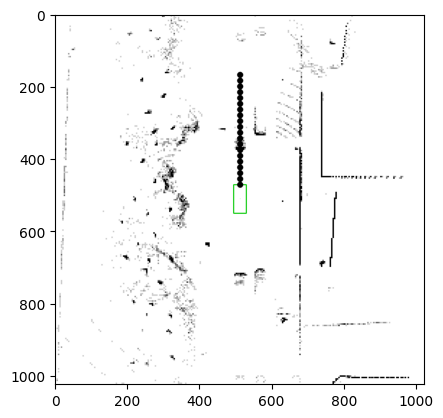

In [ ]:
plt.imshow(images_lidar)

In [ ]:
extract_data(data_point)
lidar_bev = data_point["lidar"]

seq_dim = lidar_shape[1] if len(lidar_shape := lidar_bev.shape) == 5 else 1
print(seq_dim)

2


In [ ]:
import numpy as np

shapes2 = {}
for k, v in data_point.items():
    if isinstance(v, np.ndarray):
        if v.shape == np.array(0).shape:
            continue
        else:
            shapes2[k] = v.shape
            print(f"'{k}': shape[{v.shape}]")

A bounding box sample. This is predicted for all vehicles within the lidar range (I think):
```json
{
    'class': 'ego_car', 
    'extent': [2.3, 0.1, 0.5], 
    'position': [0.0, 0.0, 0.0], 
    'yaw': 0.0,
    'num_points': -1, 
    'distance': -1, 
    'speed': 5.3, 
    'brake': 0.0, 
    'id': 3695, 
    'matrix': [
        [-0.2, -0.3, 0.1, 155.7], 
        [0.2, -0.3, -0.4, 6282.6], 
        [0.3, -3.2, 0.2, 357.1], 
        [0.0, 0.0, 0.0, 1.0]
    ]
}
```
To keep the same shape across batch items, the bounding boxes are padded according to config.max_num_bbs.

In [ ]:
print(data_point.keys())
print()
inputs = extract_data(data_point)
print({k: v.shape for k, v in inputs.items()})
print()
targets = {k: v for k, v in extract_targets(data_point).items()}
print({k: v.shape for k, v in targets.items()})

dict_keys(['rgb', 'lidar', 'target_point', 'target_point_next', 'route', 'brake', 'angle_index', 'target_speed', 'target_speed_twohot', 'semantic', 'bev_semantic', 'depth', 'bounding_boxes', 'center_heatmap', 'wh', 'yaw_class', 'yaw_res', 'offset', 'velocity', 'brake_target', 'pixel_weight', 'avg_factor', 'steer', 'throttle', 'light', 'stop_sign', 'junction', 'speed', 'theta', 'command', 'next_command'])

{'rgb': torch.Size([16, 2, 3, 384, 1024]), 'lidar_bev': torch.Size([16, 2, 1, 256, 256]), 'target_point': torch.Size([16, 2, 2]), 'ego_vel': torch.Size([16, 1, 2]), 'command': torch.Size([16, 2, 6])}

{'target_speed_label': torch.Size([16, 2, 8]), 'checkpoint_label': torch.Size([16, 2, 20, 2]), 'semantic_label': torch.Size([16, 2, 384, 1024]), 'bev_semantic_label': torch.Size([16, 2, 256, 256]), 'depth_label': torch.Size([16, 2, 384, 1024]), 'center_heatmap_label': torch.Size([16, 2, 5, 64, 64]), 'wh_label': torch.Size([16, 2, 2, 64, 64]), 'yaw_class_label': torch.Size([16, 2, 64, 64]

In [ ]:
from video_resnet import VideoResNet

image_encoder = VideoResNet(2, False)


def forward_layer_block(layers, return_layers, features):
    for name, module in layers:
        features = module(features)
        if name in return_layers:
            break
    return features


layers = iter(image_encoder.items())
return_layers = image_encoder.return_layers
image_features = data_point["temporal_rgb"].float()

/cluster/home/andrebw/.conda/envs/lb2/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/cluster/home/andrebw/.conda/envs/lb2/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
from config import GlobalConfig
from data import CARLA_Data
from transfuser import TransfuserBackbone
import torch

config = GlobalConfig()
config.image_architecture = "regnety_032"
config.lidar_architecture = "regnety_032"
config.img_seq_len = 1
config.lidar_seq_len = 1
config.seq_len = 2
config.normalize_imagenet = True
config.temporal_module = True

config.initialize(
    root_dir=[
        "/cluster/work/andrebw/repos/temporal_garage/results/data/garage_v2_2025_03_15/data"
    ]
)
dataset = CARLA_Data(
    root=config.data_roots,
    config=config,
    estimate_class_distributions=config.estimate_class_distributions,
    estimate_sem_distribution=config.estimate_semantic_distribution,
)
device = "cuda"
BZ = 16
loader = iter(torch.utils.data.DataLoader(dataset, batch_size=BZ))


def extract_data(batch):
    return {
        "rgb": batch.get("temporal_rgb", batch["rgb"]).float().to(device),
        "lidar_bev": batch["lidar"].float().to(device),
        "target_point": batch["target_point"].float().to(device),
        "ego_vel": batch["speed"].float().unsqueeze(1).to(device),
        "command": batch["command"].float().to(device),
    }


data_point = next(loader)
data = extract_data(data_point)
tf = TransfuserBackbone(config).to(device)
tf.forward(data["rgb"], data["lidar_bev"])

Setting:  all
100%|██████████| 3/3 [00:03<00:00,  1.17s/it]
Loading 8827 lidars from 3 folders
Total amount of routes: 77
Skipped routes: 2
Trainable routes: 75


IndexError: index 2 is out of bounds for dimension 1 with size 2

In [ ]:
from data import CARLA_Data

from config import GlobalConfig
import torch

config = GlobalConfig()
config.augment = False
config.use_color_aug = False
config.augment_percentage = 1
config.color_aug_prob = 1
config.seq_len = 2
config.seq_step = 1
config.img_seq_len = 1
config.img_step_size = 1
config.lidar_seq_len = 1
config.use_temporal_fusion = True
config.use_temporal_attn_weights = True
config.use_learnable_historic_initialization = False
config.normalize_imagenet = True
config.temporal_fusion_heads = 4
config.initialize(
    root_dir=[
        "/cluster/work/andrebw/repos/temporal_garage/results/data/garage_v2_2025_03_15/data"
    ]
)
dataset = CARLA_Data(
    root=config.data_roots,
    config=config,
    estimate_class_distributions=config.estimate_class_distributions,
    estimate_sem_distribution=config.estimate_semantic_distribution,
)

device = "cuda"
BZ = 2 #// config.seq_len
loader = iter(torch.utils.data.DataLoader(dataset, batch_size=BZ))


def extract_data(batch):
    return {
        "rgb": batch.get("temporal_rgb", batch["rgb"]).float().to(device),
        # "rgb": batch["rgb"].float().to(device),
        # "lidar_bev": batch.get("temporal_lidar", batch["lidar"]).float().to(device),
        "lidar_bev": batch["lidar"].float().to(device),
        "target_point": batch["target_point"].float().to(device),
        "ego_vel": batch["speed"].float().unsqueeze(1).to(device),
        # "ego_vel": vel.unsqueeze(1) if (vel:=batch["speed"].float().to(device)).shape.__len__()==1 else vel.unsqueeze(2),
        "command": batch["command"].float().to(device),
    }


def extract_targets(batch):
    return {
        "target_speed_label": batch["target_speed_twohot"].float().to(device),
        "checkpoint_label": batch["route"][:, : config.predict_checkpoint_len]
        .float()
        .to(device),
        "semantic_label": batch["semantic"].long().to(device),
        "bev_semantic_label": batch["bev_semantic"].long().to(device),
        "depth_label": batch["depth"].float().to(device),
        "center_heatmap_label": batch["center_heatmap"].float().to(device),
        "wh_label": batch["wh"].float().to(device),
        "yaw_class_label": batch["yaw_class"].long().to(device),
        "yaw_res_label": batch["yaw_res"].float().to(device),
        "offset_label": batch["offset"].float().to(device),
        "velocity_label": batch["velocity"].float().to(device),
        "brake_target_label": batch["brake_target"].long().to(device),
        "pixel_weight_label": batch["pixel_weight"].float().to(device),
        "avg_factor_label": batch["avg_factor"].float().to(device),
    }


def select(data, i):
    return {k: v[:, i] for k, v in data.items()}


loss_history = []
data_point = next(loader)
# if config.seq_len > 1:
#     data_point = {
#         k: v[:, -1]
#         for k, v in data_point.items()
#         if k not in ["rgb", "lidar_bev", "target_point", "ego_vel", "command"]
#     }

Setting:  all
100%|██████████| 3/3 [00:02<00:00,  1.22it/s]
Loading 8827 lidars from 3 folders
Total amount of routes: 77
Skipped routes: 2
Trainable routes: 75


In [ ]:
from model import LidarCenterNet

net = LidarCenterNet(config).train().to(device)
total_params = sum(p.numel() for p in net.parameters())
print(f"Total parameters: {total_params:_}")
# Original: 120_730_298

# Full model: 121_536_186 (+805_888, +0.67%)
# Static hist. init: 121_519_546 (+802_248, +0.67%)

# With motion decoder: 122_244_228 (+1_513_930, +1.25%)

Total parameters: 121_447_031


In [ ]:
net.load_state_dict(
    torch.load("../results/tfpp_base/model_0030.pth", map_location=device, weights_only=True), strict=False
)

_IncompatibleKeys(missing_keys=['temporal_fusor.cross_attn.in_proj_weight', 'temporal_fusor.cross_attn.in_proj_bias', 'temporal_fusor.cross_attn.out_proj.weight', 'temporal_fusor.cross_attn.out_proj.bias', 'temporal_fusor.self_attn.in_proj_weight', 'temporal_fusor.self_attn.in_proj_bias', 'temporal_fusor.self_attn.out_proj.weight', 'temporal_fusor.self_attn.out_proj.bias', 'temporal_fusor.mlp.0.weight', 'temporal_fusor.mlp.0.bias', 'temporal_fusor.mlp.2.weight', 'temporal_fusor.mlp.2.bias'], unexpected_keys=[])

In [ ]:
outputs = net(**extract_data(data_point))

(
    _,
    pred_target_speed,
    pred_checkpoint,
    pred_semantic,
    pred_bev_semantic,
    pred_depth,
    pred_bounding_box,
    pred_trajectories,
    _,
    _,
    _,
    attn_weights,
) = outputs
[o.shape if isinstance(o, torch.Tensor) else None for o in outputs]

[None,
 torch.Size([2, 8]),
 torch.Size([2, 10, 2]),
 torch.Size([2, 7, 384, 1024]),
 torch.Size([2, 11, 256, 256]),
 torch.Size([2, 384, 1024]),
 None,
 None,
 None,
 None,
 None,
 None]

In [ ]:
pred_trajectories

(tensor([[[[ 8.1908e-01,  6.8713e-01],
           [ 5.5901e-01,  2.9377e-01],
           [-1.5748e-01, -4.7911e-01],
           [ 3.3934e-01, -2.7007e-01],
           [ 3.2797e-01, -8.6973e-01],
           [ 7.6181e-01, -8.3047e-01]],
 
          [[ 3.4047e-01,  3.6901e-01],
           [-4.4449e-01, -9.2779e-01],
           [ 7.6777e-01, -4.0334e-02],
           [ 1.4635e-01, -2.1574e-01],
           [ 1.9164e-02, -1.4536e-01],
           [-7.6629e-01,  7.7215e-02]],
 
          [[ 6.4085e-01, -2.1639e-01],
           [ 2.2966e-01, -2.3502e-01],
           [-7.4977e-02, -1.2603e+00],
           [ 1.0703e+00, -2.2129e-01],
           [-1.3668e+00,  3.7930e-01],
           [-9.8432e-02,  6.3491e-01]],
 
          [[-2.2550e-01, -2.0840e-03],
           [ 8.0766e-02,  1.9247e-01],
           [-2.5355e-01, -4.9875e-01],
           [ 5.6157e-01, -1.9901e-01],
           [-4.2398e-01,  2.4280e-01],
           [ 3.9755e-01, -1.2515e-01]],
 
          [[-5.2385e-02,  6.7020e-02],
           [ 

In [ ]:
# targets['checkpoint_label'].shape
data_point["route"][:, -1].shape

torch.Size([2, 20, 2])

In [ ]:
from tqdm import tqdm

for batch in tqdm(loader):
    # Select the last seq item
    targets = {
        k: (
            v[:, -1] if config.seq_len > 1 and k not in ["rgb", "lidar_bev", "target_point", "ego_vel", "command"] 
            else v
        )
        for k, v in batch.items()
    }
    targets = extract_targets(targets)
    data = extract_data(batch)

    (
        _,
        pred_target_speed,
        pred_checkpoint,
        pred_semantic,
        pred_bev_semantic,
        pred_depth,
        pred_bounding_box,
        _,
        _,
        _,
        attn_weights,
    ) = net.forward(
        **data,
    )
    losses = net.compute_loss(
        pred_target_speed=pred_target_speed,
        pred_checkpoint=pred_checkpoint,
        pred_semantic=pred_semantic,
        pred_bev_semantic=pred_bev_semantic,
        pred_depth=pred_depth,
        pred_bounding_box=pred_bounding_box,
        **targets,
    )
    loss = 0
    for k, v in losses.items():
        loss += v
    loss.backward()
    loss_history.append(loss.item())
# (
#     pred_target_speed.shape,
#     pred_checkpoint.shape,
#     pred_semantic.shape,
#     pred_bev_semantic.shape,
#     pred_depth.shape,
#     (len(pred_bounding_box), pred_bounding_box[0].shape),
#     weights,
# )

  0%|          | 0/4414 [00:00<?, ?it/s]


NameError: name 'net' is not defined

In [ ]:
from trajectory_head import MotionTransformer

motion_head = MotionTransformer(d_model=256, n_layers=2, n_queries=10, future_steps=6).to(device)
total_params = sum(p.numel() for p in motion_head.parameters())
print(f"Total parameters: {total_params:_}")


Total parameters: 1_587_469


In [ ]:
traj_pred, confidence = motion_head.forward(torch.zeros(2, 65, 256).to(device))
traj_pred.shape, confidence.shape

(torch.Size([2, 10, 6, 2]), torch.Size([2, 10]))

In [ ]:
(
    pred_target_speed.shape,
    pred_checkpoint.shape,
    pred_semantic.shape,
    pred_bev_semantic.shape,
    pred_depth.shape,
    (len(pred_bounding_box), pred_bounding_box[0].shape),
    feature.shape,
)

(torch.Size([2, 8]),
 torch.Size([2, 10, 2]),
 torch.Size([2, 7, 384, 1024]),
 torch.Size([2, 11, 256, 256]),
 torch.Size([2, 384, 1024]),
 (7, torch.Size([2, 5, 64, 64])),
 torch.Size([2, 65, 256]))

### Losses

The loss is an aggregate of all the losses from the different heads used in the model.

#### Main predictions

The main predictions are target speed and checkpoint, so the losses will be:
- `loss_target_speed`
- `loss_checkpoint`

#### Bounding boxes

The bounding box prediction is based on the Center Net implementation (which in this case is based on lidar BEV images, so it's called LidarCenterNet). We have

Bounding box losses:
- `loss_center_heatmap`
- `loss_wh`
- `loss_offset`
- `loss_yaw_class`
- `loss_yaw_res`
- `loss_velocity` is only calculated when using a sequence length of > 1 (either lidar or whole sequence)

There is also functionality for loading future bounding boxes, but this is only enabled for PlanT runs. If we want to predict future trajectories, maybe this could be used for a temporal TF++ too? 

## Loading data

What we want to load is:
- rgb (.png)
- lidar_bev (.lav)
- semantic (.png)
- bev_semantic (.png)
- depth (.png)
- boxes (.json.gz)
- measurements (.json.gz)

In addition, rgb, semantic, bev_semantic and depth have *augmented* versions stored in their own file, which should be applied randomly for every data point.

Another addition, rgb and lidar_bev have temporal versions for loading sequences of them.

### \_\_init\_\_()
In init, we load all of the paths of all files we could possibly want to load, and store them as a sequence (according to seq_len). So we have shapes (size, seq, *) for each data point (size is dataset size).

When we load a file, we need to load `file[i][seq_i]`



In [ ]:
losses.keys()

dict_keys(['loss_target_speed', 'loss_checkpoint', 'loss_semantic', 'loss_bev_semantic', 'loss_depth', 'loss_center_heatmap', 'loss_wh', 'loss_offset', 'loss_yaw_class', 'loss_yaw_res'])

In [ ]:
pred_checkpoint.sub(
    data_point["route"][:4][:, : config.predict_checkpoint_len].to(device)
).abs().mean()

tensor(44.1121, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)

In [ ]:
losses

{'loss_target_speed': tensor(2.3619, device='cuda:0', grad_fn=<DivBackward1>),
 'loss_checkpoint': tensor(44.3316, device='cuda:0', grad_fn=<MeanBackward0>),
 'loss_semantic': tensor(1.9900, device='cuda:0', grad_fn=<NllLoss2DBackward0>),
 'loss_bev_semantic': tensor(2.4694, device='cuda:0', grad_fn=<NllLoss2DBackward0>),
 'loss_depth': tensor(0.3275, device='cuda:0', grad_fn=<MeanBackward0>),
 'loss_center_heatmap': tensor(869.3929, device='cuda:0', grad_fn=<DivBackward0>),
 'loss_wh': tensor(1.8131, device='cuda:0', grad_fn=<DivBackward0>),
 'loss_offset': tensor(0.5133, device='cuda:0', grad_fn=<DivBackward0>),
 'loss_yaw_class': tensor(2.4944, device='cuda:0', grad_fn=<DivBackward0>),
 'loss_yaw_res': tensor(0.0228, device='cuda:0', grad_fn=<DivBackward0>)}

In [ ]:
from trajectory_head import TrajectoryDecoder
import torch


device = "cuda"
motion_head = TrajectoryDecoder(n_dim=256, n_layers=2, n_queries=10, future_steps=2).to(device)
total_params = sum(p.numel() for p in motion_head.parameters())
print(f"Total parameters: {total_params:_}")

traj_pred, confidence = motion_head.forward(torch.zeros(2, 65, 256).to(device))
traj_pred.shape, confidence.shape

Total parameters: 1_585_670


(torch.Size([2, 10, 2, 2]), torch.Size([2, 10, 2]))

In [ ]:
preds = torch.zeros(2, 10, 2).to(device)
mask = torch.zeros(2, 10).to(device)
mask.unsqueeze(2).shape

torch.Size([2, 10, 1])

In [ ]:
from hungarian_loss import HungarianLoss

device = "cuda"
criterion = HungarianLoss()

gt_traj = torch.zeros((2,10,2,2)).to(device)
gt_traj[:,0] = torch.ones(2,2)
gt_traj.requires_grad = True

mask = torch.zeros((2,10,2)).to(device)

losses = criterion((traj_pred, confidence), gt_traj, mask=mask)
loss = sum(losses.values())
loss, losses

(tensor(0.7892, device='cuda:0', grad_fn=<AddBackward0>),
 {'loss_traj': tensor(0., device='cuda:0', grad_fn=<DivBackward0>),
  'loss_traj_confidence': tensor(0.7892, device='cuda:0', grad_fn=<NllLossBackward0>)})

In [ ]:
pred_traj[1]

tensor([[[-10.,  10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.]]], device='cuda:0', requires_grad=True)

In [ ]:
gt_traj = torch.rand((1,10,2,2)).to(device)
gt_traj[:,3,:,:] = 0.
gt_traj[:,3]

tensor([[[0., 0.],
         [0., 0.]]], device='cuda:0')